In [ ]:
import pandas as pd

df = pd.read_csv('/content/dataset.csv')

print(df.shape)
print(df.columns.tolist())

(197428, 14)
['market_id', 'created_at', 'actual_delivery_time', 'store_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

In [ ]:
df.isna().sum()

,0
market_id,987
created_at,0
actual_delivery_time,7
store_id,0
store_primary_category,4760
order_protocol,995
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0


In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

df['delivery_time_min'] = (
    df['actual_delivery_time'] - df['created_at']
).dt.total_seconds() / 60

df['delivery_time_min'].describe()

,delivery_time_min
count,197421.000000
mean,48.470956
std,320.493482
min,1.683333
25%,35.066667
50%,44.333333
75%,56.350000
max,141947.650000


In [ ]:
df['delivery_time_min'].describe(percentiles=[.25, .5, .75, .90, .95, .99])

,delivery_time_min
count,197421.000000
mean,48.470956
std,320.493482
min,1.683333
25%,35.066667
50%,44.333333
75%,56.350000
90%,70.583333
95%,81.200000
99%,107.913333


In [ ]:
df.nlargest(10, 'delivery_time_min')[
    ['created_at', 'actual_delivery_time', 'delivery_time_min']
]

,created_at,actual_delivery_time,delivery_time_min
2690,2014-10-19 05:24:15,2015-01-25 19:11:54,141947.650000
185550,2015-01-28 08:34:06,2015-02-01 16:25:25,6231.316667
27189,2015-02-16 02:24:09,2015-02-19 22:45:31,5541.366667
83055,2015-02-01 02:18:07,2015-02-01 18:08:39,950.533333
190860,2015-02-16 02:31:05,2015-02-16 17:38:32,907.450000
86952,2015-02-05 02:11:40,2015-02-05 15:34:38,802.966667
76743,2015-02-15 04:17:35,2015-02-15 16:59:00,761.416667
105825,2015-02-08 04:07:51,2015-02-08 15:03:43,655.866667
66787,2015-02-04 20:21:30,2015-02-05 07:02:27,640.950000
175971,2015-02-12 20:25:17,2015-02-13 07:01:00,635.716667


In [ ]:
(df['delivery_time_min'] > 180).sum()

np.int64(138)

In [ ]:
df[df['delivery_time_min'] > 180]['delivery_time_min'].describe()

,delivery_time_min
count,138.000000
mean,1388.557126
std,12072.166312
min,180.583333
25%,199.045833
50%,228.750000
75%,300.150000
max,141947.650000


In [ ]:
df_analysis = df[
    (df['delivery_time_min'] > 0) &
    (df['delivery_time_min'] <= 180)
].copy()

print(df_analysis.shape)

(197283, 15)


In [ ]:
df_analysis['delivery_time_min'].describe()

,delivery_time_min
count,197283.000000
mean,47.533562
std,18.041246
min,1.683333
25%,35.066667
50%,44.316667
75%,56.316667
max,179.850000


In [ ]:
# Calculate Delivery Partner Workload

df_analysis['busy_ratio'] = (
    df_analysis['total_busy_partners'] /
    df_analysis['total_onshift_partners']
)

In [ ]:
# Clean Delivery Partner Workload Ratio
import numpy as np
df_analysis['busy_ratio'] = (
    df_analysis['total_busy_partners'] /
    df_analysis['total_onshift_partners'].replace(0, np.nan)
)

df_analysis['busy_ratio'] = df_analysis['busy_ratio'].replace(
    [np.inf, -np.inf], np.nan
)

In [ ]:
# Compare Workload vs Delivery Time

workload_analysis = (
    df_analysis.dropna(subset=['busy_ratio'])
    .groupby(
        pd.qcut(df_analysis['busy_ratio'], 5, duplicates='drop')
    )['delivery_time_min']
    .mean()
)

workload_analysis

/tmp/ipykernel_881/3155072148.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


,delivery_time_min
busy_ratio,
"(-13.001, 0.781]",41.736134
"(0.781, 0.923]",45.058494
"(0.923, 1.0]",50.714050
"(1.0, 1.028]",52.101144
"(1.028, 31.0]",48.557422


In [ ]:
# Display Workload vs Delivery Time

workload_analysis

,delivery_time_min
busy_ratio,
"(-13.001, 0.781]",41.736134
"(0.781, 0.923]",45.058494
"(0.923, 1.0]",50.714050
"(1.0, 1.028]",52.101144
"(1.028, 31.0]",48.557422


In [ ]:
# Outstanding Orders vs Delivery Time

df_analysis.groupby(
    pd.qcut(
        df_analysis['total_outstanding_orders'],
        5,
        duplicates='drop'
    )
)['delivery_time_min'].mean()

/tmp/ipykernel_881/716367143.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby(


,delivery_time_min
total_outstanding_orders,
"(-6.001, 13.0]",46.173611
"(13.0, 30.0]",45.315714
"(30.0, 56.0]",44.784098
"(56.0, 99.0]",47.613131
"(99.0, 285.0]",53.949993


In [ ]:
# Calculate Orders per Available Partner

df_analysis['orders_per_partner'] = (
    df_analysis['total_outstanding_orders'] /
    df_analysis['total_onshift_partners'].replace(0, np.nan)
)

In [ ]:
# Orders per Partner vs Delivery Time

df_analysis.groupby(
    pd.qcut(
        df_analysis['orders_per_partner'],
        5,
        duplicates='drop'
    )
)['delivery_time_min'].mean()

/tmp/ipykernel_881/285560889.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby(


,delivery_time_min
orders_per_partner,
"(-16.001, 0.873]",39.847449
"(0.873, 1.103]",42.512266
"(1.103, 1.302]",45.535876
"(1.302, 1.548]",50.050440
"(1.548, 47.0]",59.016527


In [ ]:
# Delivery Time by Hour of Day

df_analysis['hour'] = df_analysis['created_at'].dt.hour

hourly_delivery = (
    df_analysis.groupby('hour')['delivery_time_min']
    .agg(['mean', 'count'])
)

hourly_delivery

,mean,count
hour,,
0,44.005322,12662
1,48.796274,28168
2,54.666638,36946
3,52.450397,27049
4,44.479290,15244
5,40.046951,7095
6,40.746669,1416
7,45.916667,11
14,67.626667,40


In [ ]:
# Order Volume and Delivery Time by Hour

hourly_analysis = (
    df_analysis.groupby('hour')
    .agg(
        orders=('delivery_time_min', 'count'),
        avg_delivery_time=('delivery_time_min', 'mean')
    )
    .sort_index()
)

hourly_analysis

,orders,avg_delivery_time
hour,,
0,12662,44.005322
1,28168,48.796274
2,36946,54.666638
3,27049,52.450397
4,15244,44.479290
5,7095,40.046951
6,1416,40.746669
7,11,45.916667
14,40,67.626667


In [ ]:
# Delivery Partner Availability vs Delivery Time

df_analysis.groupby(
    pd.qcut(
        df_analysis['total_onshift_partners'],
        5,
        duplicates='drop'
    )
)['delivery_time_min'].mean()

/tmp/ipykernel_881/2009317169.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby(


,delivery_time_min
total_onshift_partners,
"(-4.001, 14.0]",48.620397
"(14.0, 27.0]",46.005505
"(27.0, 47.0]",44.742404
"(47.0, 74.0]",47.138330
"(74.0, 171.0]",51.236425


In [ ]:
# Delivery Time by Store Category

category_analysis = (
    df_analysis.groupby('store_primary_category')
    .agg(
        orders=('delivery_time_min', 'count'),
        avg_delivery_time=('delivery_time_min', 'mean')
    )
    .sort_values('avg_delivery_time', ascending=False)
)

category_analysis.head(15)

,orders,avg_delivery_time
store_primary_category,,
spanish,37,56.178378
caribbean,253,56.098287
brazilian,310,55.972957
belgian,2,54.991667
tapas,146,54.250571
cajun,316,52.500897
malaysian,102,52.290196
japanese,9188,51.901749
burmese,821,51.635363


In [ ]:
# Store Categories with Sufficient Order Volume

category_analysis[category_analysis['orders'] >= 100].head(15)

,orders,avg_delivery_time
store_primary_category,,
caribbean,253,56.098287
brazilian,310,55.972957
tapas,146,54.250571
cajun,316,52.500897
malaysian,102,52.290196
japanese,9188,51.901749
burmese,821,51.635363
steak,1092,51.593910
sushi,2186,51.394053


In [ ]:
# Order Size vs Delivery Time

df_analysis.groupby(
    pd.qcut(
        df_analysis['total_items'],
        5,
        duplicates='drop'
    )
)['delivery_time_min'].mean()

/tmp/ipykernel_881/3826513088.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby(


,delivery_time_min
total_items,
"(0.999, 2.0]",45.423660
"(2.0, 3.0]",47.674177
"(3.0, 4.0]",49.025491
"(4.0, 411.0]",51.797993


In [ ]:
# Order Value vs Delivery Time

df_analysis.groupby(
    pd.qcut(
        df_analysis['subtotal'],
        5,
        duplicates='drop'
    )
)['delivery_time_min'].mean()

/tmp/ipykernel_881/2370436137.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby(


,delivery_time_min
subtotal,
"(-0.001, 1275.0]",42.999358
"(1275.0, 1875.0]",45.041195
"(1875.0, 2600.0]",46.756754
"(2600.0, 3780.0]",49.211246
"(3780.0, 27100.0]",53.724200


In [ ]:
# Delivery Time by Demand Pressure and Order Size

df_analysis['demand_pressure'] = pd.qcut(
    df_analysis['orders_per_partner'],
    3,
    labels=['Low', 'Medium', 'High']
)

df_analysis['order_size_group'] = pd.qcut(
    df_analysis['total_items'],
    3,
    labels=['Small', 'Medium', 'Large'],
    duplicates='drop'
)

df_analysis.groupby(
    ['demand_pressure', 'order_size_group'],
    observed=True
)['delivery_time_min'].mean()

demand_pressure  order_size_group
Low              Small               39.052469
                 Medium              40.881310
                 Large               43.757653
Medium           Small               43.622918
                 Medium              45.668733
                 Large               48.448541
High             Small               53.641928
                 Medium              55.878790
                 Large               58.887729
Name: delivery_time_min, dtype: float64

In [ ]:
# Order Share by Demand Pressure

df_analysis['demand_pressure'].value_counts(normalize=True).sort_index() * 100

,proportion
demand_pressure,
Low,33.350993
Medium,33.616448
High,33.032559


In [ ]:
# Business Impact of High Demand Pressure

df_analysis.groupby('demand_pressure')['delivery_time_min'].agg(
    orders='count',
    avg_delivery_time='mean',
    median_delivery_time='median'
)

/tmp/ipykernel_881/3627431244.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby('demand_pressure')['delivery_time_min'].agg(


,orders,avg_delivery_time,median_delivery_time
demand_pressure,,,
Low,59175,40.833839,38.300000
Medium,59646,45.581561,43.116667
High,58610,55.843263,52.716667


In [ ]:
# Market-wise Delivery Performance

market_analysis = (
    df_analysis.groupby('market_id')
    .agg(
        orders=('delivery_time_min', 'count'),
        avg_delivery_time=('delivery_time_min', 'mean'),
        median_delivery_time=('delivery_time_min', 'median')
    )
    .sort_values('avg_delivery_time', ascending=False)
)

market_analysis

,orders,avg_delivery_time,median_delivery_time
market_id,,,
1.0,37995,51.107100,46.866667
3.0,23279,47.504112,44.083333
4.0,47568,47.110460,44.400000
6.0,14436,47.032263,43.566667
5.0,17989,46.380849,43.416667
2.0,55029,45.944940,43.333333


In [ ]:
# Demand Pressure vs Delivery Time by Market

market_pressure = (
    df_analysis.groupby(
        ['market_id', 'demand_pressure'],
        observed=True
    )['delivery_time_min']
    .mean()
    .unstack()
)

market_pressure

demand_pressure,Low,Medium,High
market_id,,,
1.0,43.886075,48.572408,60.311454
2.0,38.575879,43.617434,52.985549
3.0,42.867543,48.314620,57.929741
4.0,38.448883,44.153076,55.395425
5.0,40.761826,48.251437,58.022522
6.0,41.084647,44.194493,56.458730


In [ ]:
# Final Analysis Summary

overall_summary = pd.DataFrame({
    'Metric': [
        'Total Orders',
        'Average Delivery Time (min)',
        'Median Delivery Time (min)',
        '90th Percentile Delivery Time (min)',
        'High Demand Orders (%)',
        'High Demand Avg Delivery Time (min)',
        'Low Demand Avg Delivery Time (min)'
    ],
    'Value': [
        len(df_analysis),
        df_analysis['delivery_time_min'].mean(),
        df_analysis['delivery_time_min'].median(),
        df_analysis['delivery_time_min'].quantile(0.90),
        (df_analysis['demand_pressure'] == 'High').mean() * 100,
        df_analysis.loc[
            df_analysis['demand_pressure'] == 'High',
            'delivery_time_min'
        ].mean(),
        df_analysis.loc[
            df_analysis['demand_pressure'] == 'Low',
            'delivery_time_min'
        ].mean()
    ]
})

overall_summary

,Metric,Value
0,Total Orders,197283.000000
1,Average Delivery Time (min),47.533562
2,Median Delivery Time (min),44.316667
3,90th Percentile Delivery Time (min),70.483333
4,High Demand Orders (%),29.708591
5,High Demand Avg Delivery Time (min),55.843263
6,Low Demand Avg Delivery Time (min),40.833839


In [ ]:
# Demand Pressure Summary

demand_summary = (
    df_analysis.groupby('demand_pressure', observed=True)
    .agg(
        orders=('delivery_time_min', 'count'),
        avg_delivery_time=('delivery_time_min', 'mean'),
        median_delivery_time=('delivery_time_min', 'median')
    )
    .reset_index()
)

demand_summary

,demand_pressure,orders,avg_delivery_time,median_delivery_time
0,Low,59175,40.833839,38.300000
1,Medium,59646,45.581561,43.116667
2,High,58610,55.843263,52.716667


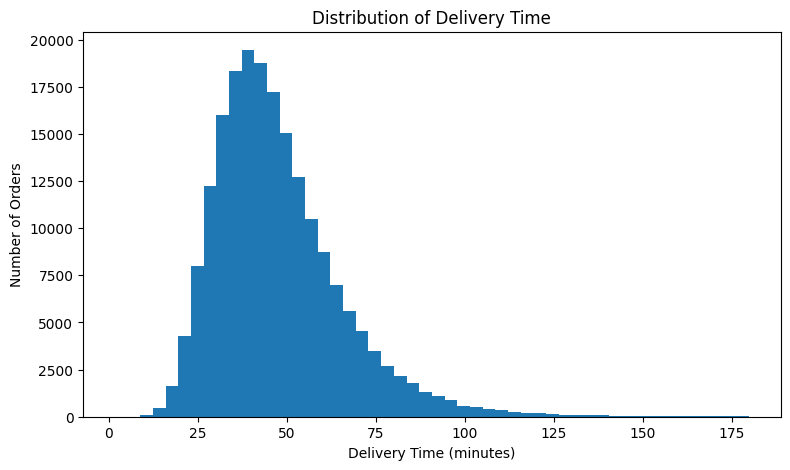

In [ ]:
# Overall Delivery Time Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.hist(
    df_analysis['delivery_time_min'].dropna(),
    bins=50
)
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Delivery Time')
plt.show()

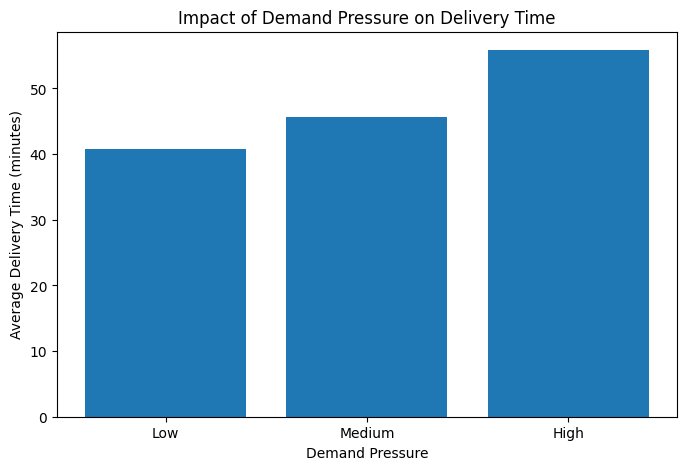

In [ ]:
# Demand Pressure vs Delivery Time

demand_chart = (
    df_analysis.groupby('demand_pressure', observed=True)['delivery_time_min']
    .mean()
    .reindex(['Low', 'Medium', 'High'])
)

plt.figure(figsize=(8, 5))
plt.bar(
    demand_chart.index,
    demand_chart.values
)
plt.xlabel('Demand Pressure')
plt.ylabel('Average Delivery Time (minutes)')
plt.title('Impact of Demand Pressure on Delivery Time')
plt.show()

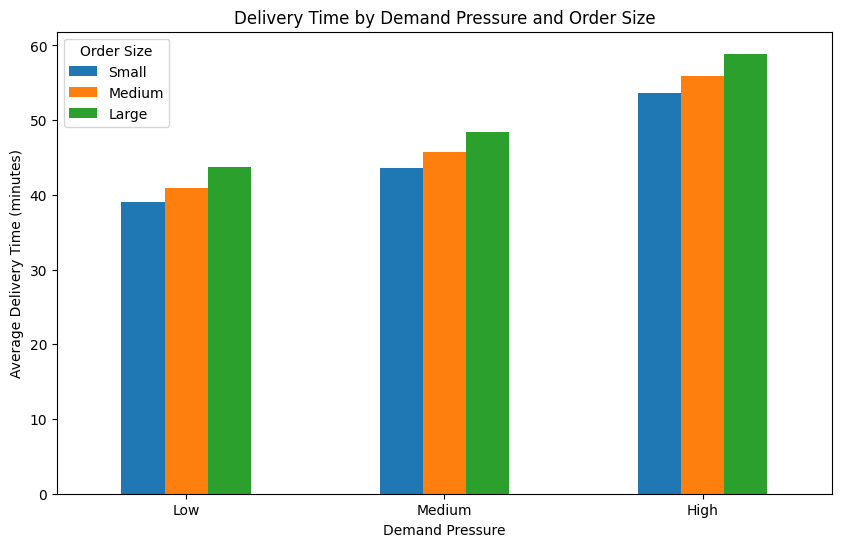

In [ ]:
# Demand Pressure and Order Size vs Delivery Time

rca_chart = (
    df_analysis.groupby(
        ['demand_pressure', 'order_size_group'],
        observed=True
    )['delivery_time_min']
    .mean()
    .unstack()
    .reindex(['Low', 'Medium', 'High'])
)

ax = rca_chart.plot(
    kind='bar',
    figsize=(10, 6)
)

ax.set_xlabel('Demand Pressure')
ax.set_ylabel('Average Delivery Time (minutes)')
ax.set_title('Delivery Time by Demand Pressure and Order Size')
ax.legend(title='Order Size')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_881/3812202427.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby(


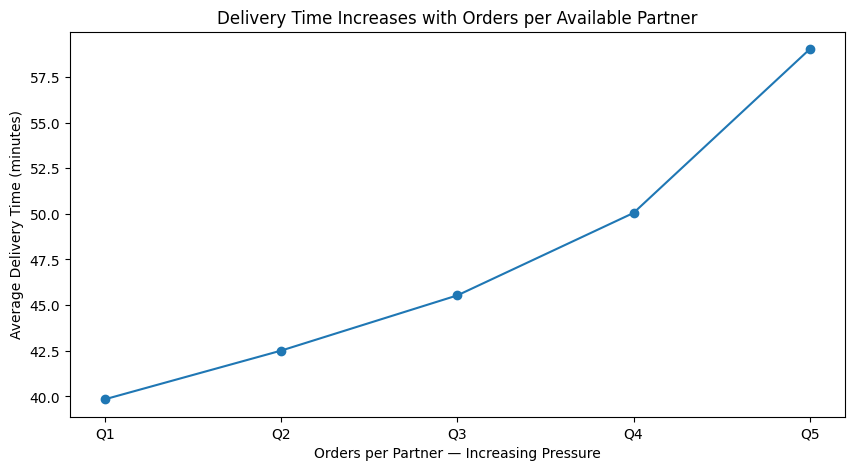

In [ ]:
# Orders per Partner vs Delivery Time

pressure_chart = (
    df_analysis.groupby(
        pd.qcut(
            df_analysis['orders_per_partner'],
            5,
            duplicates='drop'
        )
    )['delivery_time_min']
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(pressure_chart) + 1),
    pressure_chart.values,
    marker='o'
)
plt.xlabel('Orders per Partner — Increasing Pressure')
plt.ylabel('Average Delivery Time (minutes)')
plt.title('Delivery Time Increases with Orders per Available Partner')
plt.xticks(
    range(1, len(pressure_chart) + 1),
    [f'Q{i}' for i in range(1, len(pressure_chart) + 1)]
)
plt.show()

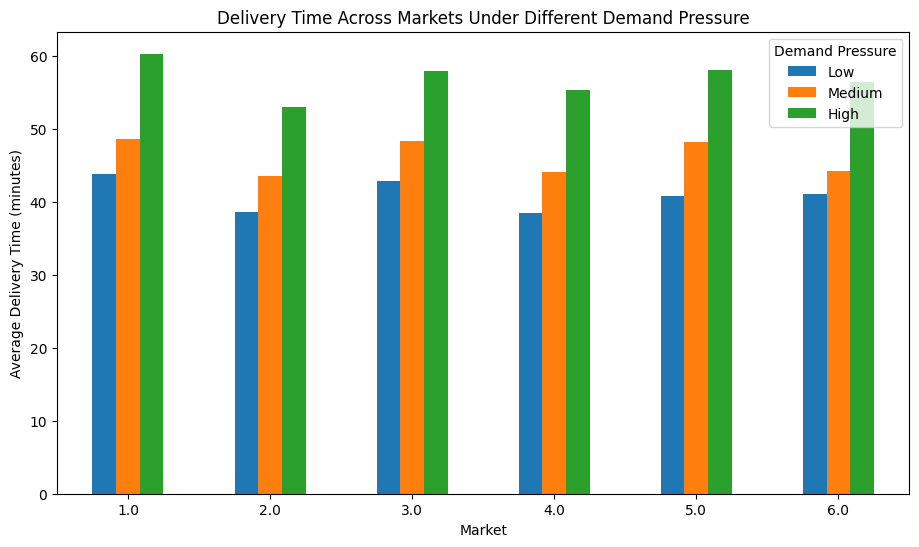

In [ ]:
# Market and Demand Pressure vs Delivery Time

market_chart = (
    df_analysis.groupby(
        ['market_id', 'demand_pressure'],
        observed=True
    )['delivery_time_min']
    .mean()
    .unstack()
    .reindex(columns=['Low', 'Medium', 'High'])
)

ax = market_chart.plot(
    kind='bar',
    figsize=(11, 6)
)

ax.set_xlabel('Market')
ax.set_ylabel('Average Delivery Time (minutes)')
ax.set_title('Delivery Time Across Markets Under Different Demand Pressure')
ax.legend(title='Demand Pressure')
plt.xticks(rotation=0)
plt.show()

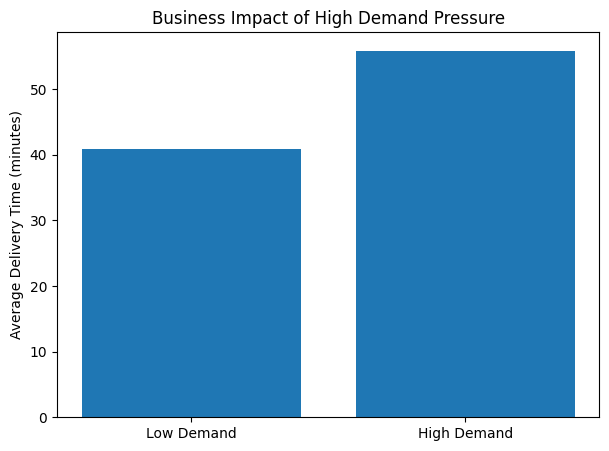

In [ ]:
# Low vs High Demand Business Impact

impact_chart = pd.Series({
    'Low Demand': df_analysis.loc[
        df_analysis['demand_pressure'] == 'Low',
        'delivery_time_min'
    ].mean(),
    'High Demand': df_analysis.loc[
        df_analysis['demand_pressure'] == 'High',
        'delivery_time_min'
    ].mean()
})

plt.figure(figsize=(7, 5))
plt.bar(
    impact_chart.index,
    impact_chart.values
)
plt.ylabel('Average Delivery Time (minutes)')
plt.title('Business Impact of High Demand Pressure')
plt.show()

In [2]:
# Check CSV Data Types

df.dtypes

NameError: name 'df' is not defined

In [3]:
# Load Delivery Dataset

import pandas as pd

df = pd.read_csv('/content/dataset.csv')

print(df.shape)

(197428, 14)


In [4]:
# Check Data Types

df.dtypes

,0
market_id,float64
created_at,object
actual_delivery_time,object
store_id,object
store_primary_category,object
order_protocol,float64
total_items,int64
subtotal,int64
num_distinct_items,int64
min_item_price,int64


In [5]:
# Check Missing Values

df.isna().sum()A

,0
market_id,987
created_at,0
actual_delivery_time,7
store_id,0
store_primary_category,4760
order_protocol,995
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0


In [6]:
# Prepare CSV for MySQL Import

import pandas as pd
import numpy as np

df = pd.read_csv('/content/dataset.csv')

# Convert datetime columns to MySQL-compatible format
df['created_at'] = pd.to_datetime(
    df['created_at'],
    errors='coerce'
).dt.strftime('%Y-%m-%d %H:%M:%S')

df['actual_delivery_time'] = pd.to_datetime(
    df['actual_delivery_time'],
    errors='coerce'
).dt.strftime('%Y-%m-%d %H:%M:%S')

# Convert numeric columns
numeric_columns = [
    'market_id',
    'order_protocol',
    'total_items',
    'subtotal',
    'num_distinct_items',
    'min_item_price',
    'max_item_price',
    'total_onshift_partners',
    'total_busy_partners',
    'total_outstanding_orders'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Keep store_id as text
df['store_id'] = df['store_id'].astype(str).replace('nan', '')

# Replace missing values with blank cells
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna('')

# Save MySQL-ready CSV
df.to_csv(
    '/content/dataset_mysql.csv',
    index=False
)

print(df.shape)
print('MySQL-ready CSV created successfully')

(197428, 14)
MySQL-ready CSV created successfully


In [7]:
# Install MySQL Connector

!pip -q install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 54.9 MB/s eta 0:00:00


In [8]:
# Check MySQL Connector

import mysql.connector

print("Connector ready")

Connector ready
